# Analyze with real-world data

In [1]:
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()
nltk.download('vader_lexicon')
nltk.download('subjective')
nltk.download('movie_reviews')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\dines\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Error loading subjective: Package 'subjective' not found
[nltk_data]     in index
[nltk_data] Downloading package movie_reviews to
[nltk_data]     C:\Users\dines\AppData\Roaming\nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!


True

In [2]:
import pandas as pd
ds = pd.read_csv('../07_Data_Science/Data_Set/stockerbot-export.csv' , on_bad_lines='skip')
ds

,id,text,timestamp,source,symbols,company_names,url,verified
0,1019696670777503700,VIDEO: “I was in my office. I was minding my o...,Wed Jul 18 21:33:26 +0000 2018,GoldmanSachs,GS,The Goldman Sachs,https://twitter.com/i/web/status/1019696670777...,True
1,1019709091038548000,The price of lumber $LB_F is down 22% since hi...,Wed Jul 18 22:22:47 +0000 2018,StockTwits,M,Macy's,https://twitter.com/i/web/status/1019709091038...,True
2,1019711413798035500,Who says the American Dream is dead? https://t...,Wed Jul 18 22:32:01 +0000 2018,TheStreet,AIG,American,https://buff.ly/2L3kmc4,True
3,1019716662587740200,Barry Silbert is extremely optimistic on bitco...,Wed Jul 18 22:52:52 +0000 2018,MarketWatch,BTC,Bitcoin,https://twitter.com/i/web/status/1019716662587...,True
4,1019718460287389700,How satellites avoid attacks and space junk wh...,Wed Jul 18 23:00:01 +0000 2018,Forbes,ORCL,Oracle,http://on.forbes.com/6013DqDDU,True
...,...,...,...,...,...,...,...,...
28259,1019730088617635800,$FB : 29234a9c-7f08-4d5a-985f-cb1a5554ecf9,Wed Jul 18 23:46:13 +0000 2018,test5f1798,FB,Facebook,NaN,False
28260,1019730115524288500,【仮想通貨】ビットコインの価格上昇、８０万円台回復 約１カ月半ぶり $BTC ht...,Wed Jul 18 23:46:19 +0000 2018,keizai_toushi17,BTC,Bitcoin,http://keizai-toushi-navi.com/?p=26838,False
28261,1019730115805184000,RT @invest_in_hd: 'Nuff said! $TEL #telcoin #...,Wed Jul 18 23:46:19 +0000 2018,iad81,BTC,Bitcoin,https://twitter.com/CRYPTOVERLOAD/status/10178...,False
28262,1019730117252341800,【仮想通貨】ビットコインの価格上昇、８０万円台回復 約１カ月半ぶり $BTC ht...,Wed Jul 18 23:46:20 +0000 2018,O8viWMyrCV6cBOZ,BTC,Bitcoin,http://true.velvet.jp/monexx/archives/2357,False


In [3]:
ds.describe()

,id
count,2.826400e+04
mean,1.018834e+18
std,9.911911e+14
min,9.671094e+17
25%,1.018364e+18
50%,1.019222e+18
75%,1.019585e+18
max,1.019743e+18


In [4]:
ds['symbols'].unique()

array(['GS', 'M', 'AIG', 'BTC', 'ORCL', 'FB-GOOGL-GOOG', 'HRS',
       'INTC-USB', 'NFLX', 'TWX', 'ENDP', 'HPQ', 'MGM', 'AMZN-GPS', 'UDR',
       'ticker', 'NTRS', 'CBS', 'BLK', 'GOOGL', 'EBAY', 'JD', 'TWTR',
       'FB', 'FIS', 'AJG', 'INFO', 'FLR', 'AVY', 'ETR', 'XYL', 'IRM',
       'ORLY', 'AVB', 'HP', 'MOS', 'HSY', 'NI', 'AMG', 'HCA', 'JEC',
       'ODP', 'COO', 'SNPS', 'ARRY', 'REG', 'RHI', 'DLTR', 'FNSR', 'NVAX',
       'ANSS', 'PNR', 'DDR', 'EL', 'EXPD', 'AEE', 'AON', 'LH', 'ALLE',
       'AIV', 'RE', 'WU', 'WRK', 'AAP', 'OKE', 'XRAY', 'MTD', 'TMK',
       'SLM', 'SRCL', 'IP', 'EMN', 'NUAN', 'AKAM', 'TRQ', 'GNTX', 'DCIX',
       'FBHS', 'ZBH', 'BXP', 'MAA', 'KIM', 'HIBB', 'CNP', 'PAH', 'WYN',
       'TROW', 'ECL', 'LUK', 'WM', 'AZO', 'HIG', 'AES', 'FMSA', 'QRVO',
       'CX', 'HDS', 'WLTW', 'MUR', 'ROP', 'DLPH', 'GNCA', 'ED', 'HSIC',
       'ROST', 'VAR', 'UHS', 'FRT', 'ZTS', 'HOLX', 'DTE', 'ETE', 'AEP',
       'TMO', 'PTEN', 'FLEX', 'XL', 'PDCO', 'HCP', 'MON', 'COL', 'CINF',
  

In [5]:
ds['symbols'].value_counts()

symbols
NFLX             101
MTB              100
MOMO             100
HON              100
AMAT             100
                ... 
AMZN-GPS           1
ORCL               1
FB-GOOGL-GOOG      1
M                  1
GS                 1
Name: count, Length: 453, dtype: int64

In [6]:
ds[ds['symbols'] == 'NFLX']
nflx_sort = ds.sort_values(by='timestamp')
nflx_sort

,id,text,timestamp,source,symbols,company_names,url,verified
26,967109381098758100,New time: Janet Yellen and I in conversation a...,Fri Feb 23 18:50:19 +0000 2018,benbernanke,FB,Facebook,https://twitter.com/i/web/status/9671093810987...,True
4196,1017559236161794000,Short sale volume (not short interest) for $XL...,Fri Jul 13 00:00:01 +0000 2018,shortvolumes,TRQ,Turquoise Hill Resources Ltd.,http://shortvolumes.com/?t=XLY,False
4197,1017559619156283400,Please just look at the tweet and reply’s $qqq...,Fri Jul 13 00:01:33 +0000 2018,OneOClockDrop,FNSR,Finisar Corporation,https://twitter.com/i/web/status/1017559619156...,False
4198,1017559821795684400,Boston Properties Inc. $BXP Analysts See $1.56...,Fri Jul 13 00:02:21 +0000 2018,whatsonthorold2,BXP,Boston Properties,https://www.whatsonthorold.com/2018/07/13/bost...,False
4199,1017559885565661200,RT @Ro_Patel: S&amp;P 500 CO.s w/ most rev exp...,Fri Jul 13 00:02:36 +0000 2018,DerKomizar2,MCHP,Microchip Technology Incorporated,NaN,False
...,...,...,...,...,...,...,...,...
28259,1019730088617635800,$FB : 29234a9c-7f08-4d5a-985f-cb1a5554ecf9,Wed Jul 18 23:46:13 +0000 2018,test5f1798,FB,Facebook,NaN,False
28260,1019730115524288500,【仮想通貨】ビットコインの価格上昇、８０万円台回復 約１カ月半ぶり $BTC ht...,Wed Jul 18 23:46:19 +0000 2018,keizai_toushi17,BTC,Bitcoin,http://keizai-toushi-navi.com/?p=26838,False
28261,1019730115805184000,RT @invest_in_hd: 'Nuff said! $TEL #telcoin #...,Wed Jul 18 23:46:19 +0000 2018,iad81,BTC,Bitcoin,https://twitter.com/CRYPTOVERLOAD/status/10178...,False
28262,1019730117252341800,【仮想通貨】ビットコインの価格上昇、８０万円台回復 約１カ月半ぶり $BTC ht...,Wed Jul 18 23:46:20 +0000 2018,O8viWMyrCV6cBOZ,BTC,Bitcoin,http://true.velvet.jp/monexx/archives/2357,False


In [7]:
compound_scores = []

for index, row in nflx_sort.iterrows():
    tweet = row['text']
    analysis = sia.polarity_scores(tweet)
    compound_scores.append(analysis['compound'])

# compound_scores
nflx_sort['sentiment_scores'] = compound_scores
nflx_sort

,id,text,timestamp,source,symbols,company_names,url,verified,sentiment_scores
26,967109381098758100,New time: Janet Yellen and I in conversation a...,Fri Feb 23 18:50:19 +0000 2018,benbernanke,FB,Facebook,https://twitter.com/i/web/status/9671093810987...,True,0.2960
4196,1017559236161794000,Short sale volume (not short interest) for $XL...,Fri Jul 13 00:00:01 +0000 2018,shortvolumes,TRQ,Turquoise Hill Resources Ltd.,http://shortvolumes.com/?t=XLY,False,0.0000
4197,1017559619156283400,Please just look at the tweet and reply’s $qqq...,Fri Jul 13 00:01:33 +0000 2018,OneOClockDrop,FNSR,Finisar Corporation,https://twitter.com/i/web/status/1017559619156...,False,0.3182
4198,1017559821795684400,Boston Properties Inc. $BXP Analysts See $1.56...,Fri Jul 13 00:02:21 +0000 2018,whatsonthorold2,BXP,Boston Properties,https://www.whatsonthorold.com/2018/07/13/bost...,False,0.0000
4199,1017559885565661200,RT @Ro_Patel: S&amp;P 500 CO.s w/ most rev exp...,Fri Jul 13 00:02:36 +0000 2018,DerKomizar2,MCHP,Microchip Technology Incorporated,NaN,False,0.0000
...,...,...,...,...,...,...,...,...,...
28259,1019730088617635800,$FB : 29234a9c-7f08-4d5a-985f-cb1a5554ecf9,Wed Jul 18 23:46:13 +0000 2018,test5f1798,FB,Facebook,NaN,False,0.0000
28260,1019730115524288500,【仮想通貨】ビットコインの価格上昇、８０万円台回復 約１カ月半ぶり $BTC ht...,Wed Jul 18 23:46:19 +0000 2018,keizai_toushi17,BTC,Bitcoin,http://keizai-toushi-navi.com/?p=26838,False,0.0000
28261,1019730115805184000,RT @invest_in_hd: 'Nuff said! $TEL #telcoin #...,Wed Jul 18 23:46:19 +0000 2018,iad81,BTC,Bitcoin,https://twitter.com/CRYPTOVERLOAD/status/10178...,False,0.0000
28262,1019730117252341800,【仮想通貨】ビットコインの価格上昇、８０万円台回復 約１カ月半ぶり $BTC ht...,Wed Jul 18 23:46:20 +0000 2018,O8viWMyrCV6cBOZ,BTC,Bitcoin,http://true.velvet.jp/monexx/archives/2357,False,0.0000


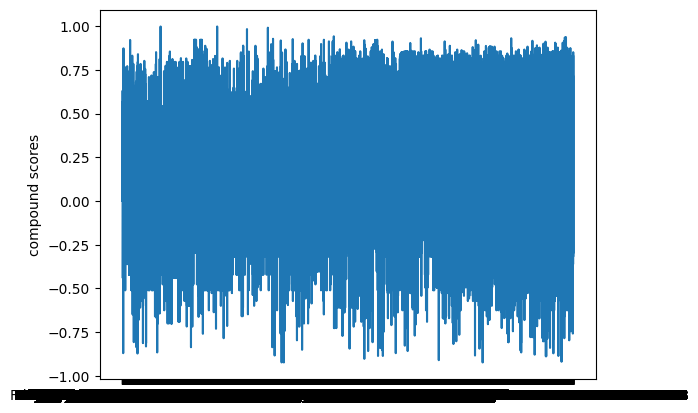

In [8]:
import matplotlib.pyplot as plt
plt.plot(nflx_sort['timestamp'] , compound_scores)
plt.ylabel('compound scores')
plt.show()
